In [ ]:
#1.Choose a classification dataset and normalize features
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv(r'C:\databases\Iris.csv')

df.drop(columns='Id', inplace=True, errors='ignore')

X = df[['SepalLengthCm', 'SepalWidthCm']].values  
y = LabelEncoder().fit_transform(df['Species'])   

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
#2.Use KNeighborsClassifier from sklearn.
from sklearn.neighbors import KNeighborsClassifier

# Example with k=3
knn = KNeighborsClassifier(n_neighbors=3)


In [9]:
#3. Experiment with different values of K

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

k_values = [1, 3, 5, 7]
models = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    models[k] = model



K = 1 | Accuracy = 0.71


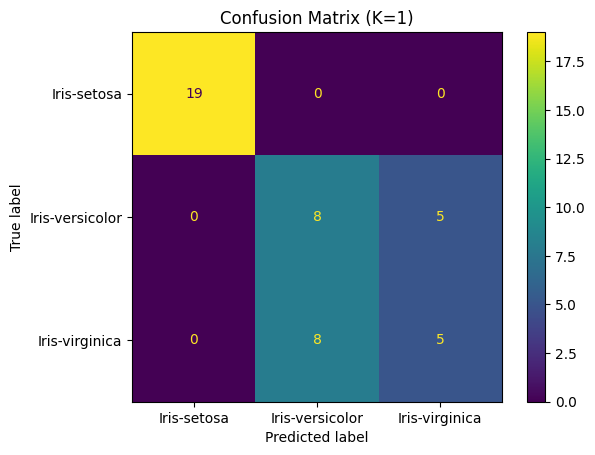


K = 3 | Accuracy = 0.84


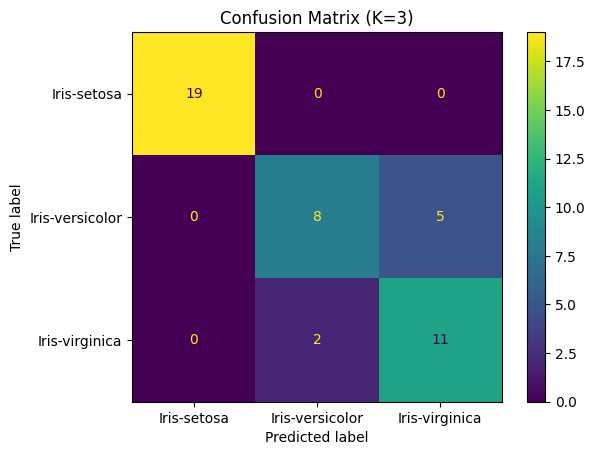


K = 5 | Accuracy = 0.82


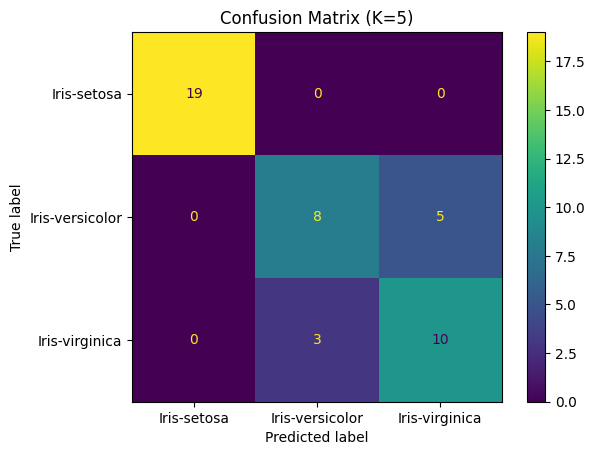


K = 7 | Accuracy = 0.80


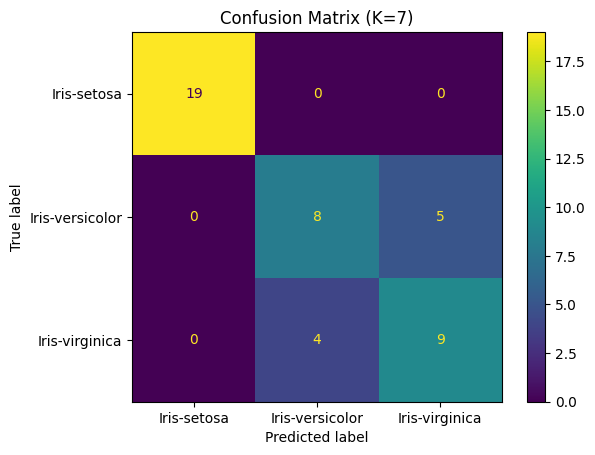

In [10]:
#4. Evaluate model using accuracy, confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

for k, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nK = {k} | Accuracy = {acc:.2f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(df['Species']))
    disp.plot()
    plt.title(f"Confusion Matrix (K={k})")
    plt.show()



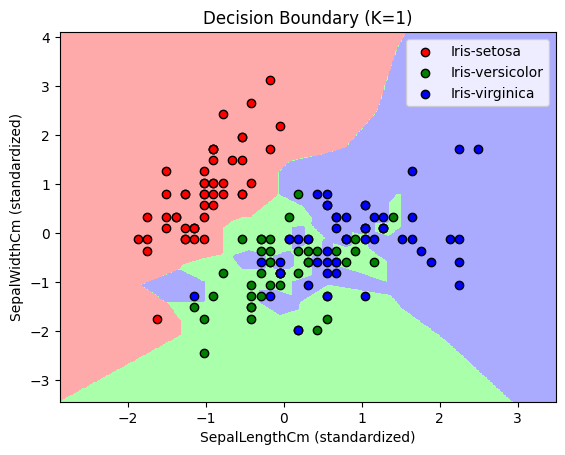

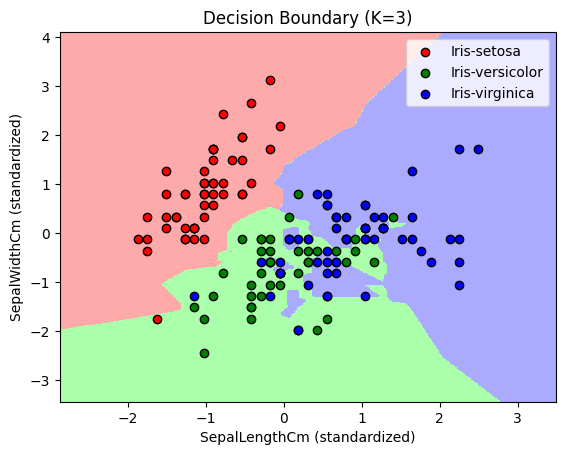

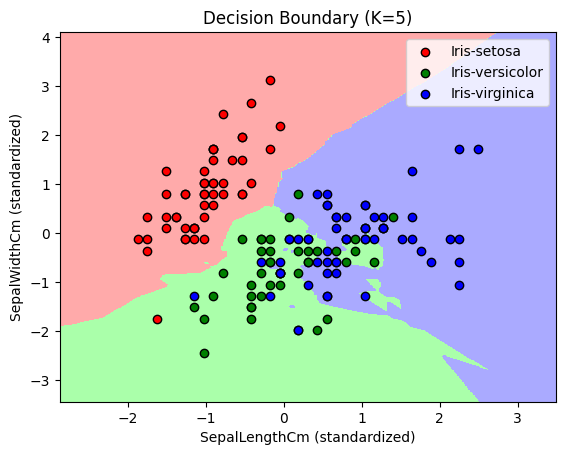

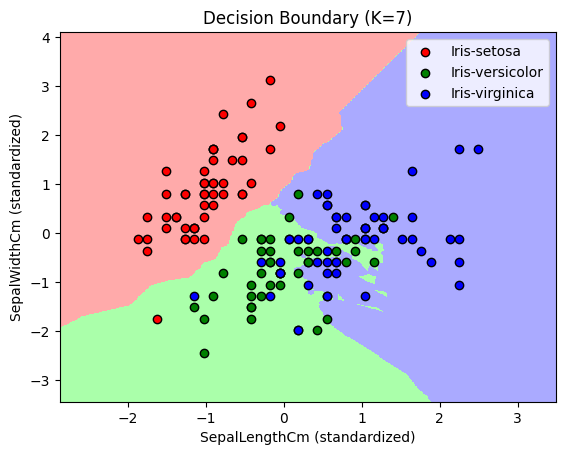

In [11]:
#5.Visualize decision boundaries.
from matplotlib.colors import ListedColormap
import numpy as np

# Visualization (only works well with 2 features)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

for k, model in models.items():
    h = .02
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    for i, color in enumerate(cmap_bold):
        plt.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1],
                    c=color, label=np.unique(df['Species'])[i], edgecolor='k')
    
    plt.xlabel('SepalLengthCm (standardized)')
    plt.ylabel('SepalWidthCm (standardized)')
    plt.title(f"Decision Boundary (K={k})")
    plt.legend()
    plt.show()
